# 01 — Exploratory Data Analysis
**Dynamic Pricing Engine** | Mohit | github.com/dswithmohit/dynamic-pricing-engine

---
### Goals
- Download the Kaggle dataset (or load cached synthetic version)
- Understand price/demand distributions across product categories
- Identify seasonality, outliers, and missing data
- Motivate the feature engineering choices in `02_feature_engineering.ipynb`

In [11]:
import os
import sys

def _find_project_root(marker="src"):
    """Walk upward from the current working directory until a folder
    containing `marker` (the src/ package) is found. This works no matter
    where Jupyter was launched from, unlike a hardcoded os.path.abspath('..').
    """
    path = os.getcwd()
    while True:
        if os.path.isdir(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError(
                f"Could not find project root (no '{marker}/' folder found "
                f"above {os.getcwd()}). Are you running Jupyter from inside "
                f"the project, or a totally different location?"
            )
        path = parent

PROJECT_ROOT = _find_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Blues_d')

from src.data_loader import download_kaggle_dataset, load_raw, build_synthetic_dataset, eda_summary

## 1. Load Data

In [12]:
# Download from Kaggle if not already present
# Requires kaggle.json in ~/.kaggle/  (chmod 600)
try:
    download_kaggle_dataset()
    df_raw = load_raw()
except FileNotFoundError:
    print('Raw file not found — generating synthetic seed instead.')
    from src.data_loader import _make_seed_df
    df_raw = _make_seed_df()

df_raw.head()

[data_loader] Raw CSV already exists at /Users/mohit/Desktop/GitHub/dynamic-pricing-engine/data/raw/retail_pricing.csv. Skipping download.
[data_loader] Renamed columns: {'category': 'product_category', 'current_price': 'unit_price'}
[data_loader] Loaded raw data — 172,800 rows × 17 cols


,date,product_id,product_category,brand,region,channel,season,base_price,unit_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,NaN,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,312,0,116.07
3,2026-01-04,P1001,Shoes,Nike,AU,web,Winter,173.55,164.87,-5.0,5,Member Offer,13,2143.31,227,0,116.07
4,2026-01-05,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,247,0,116.07


In [13]:
eda_summary(df_raw)


EDA SUMMARY
Shape          : (172800, 17)


Date range     : 2026-01-01 00:00:00 → 2026-03-31 00:00:00

Null counts (top 10):
promotion_type      100155
date                     0
product_id               0
brand                    0
product_category         0
channel                  0
season                   0
base_price               0
region                   0
unit_price               0
dtype: int64

Numeric describe:
                                 mean          std                  min  \
date              2026-02-14 12:00:00          NaN  2026-01-01 00:00:00   
base_price                 221.370656   125.659903                 8.55   
unit_price                  197.82836   118.293731                 4.28   
price_change_pct           -10.657955    14.559533               -50.03   
discount_pct                10.657957     14.55951                  0.0   
units_sold                  14.120735     8.344558                  0.0   
revenue                   2757.295723  2410.520529                  0.0   
inventory_level 

## 2. Price Distribution

In [14]:
print(df_raw.columns.tolist())
df_raw.head(3)

['date', 'product_id', 'product_category', 'brand', 'region', 'channel', 'season', 'base_price', 'unit_price', 'price_change_pct', 'discount_pct', 'promotion_type', 'units_sold', 'revenue', 'inventory_level', 'stockout_flag', 'demand_index']


,date,product_id,product_category,brand,region,channel,season,base_price,unit_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2026-01-01,P1001,Shoes,Nike,AU,mobile,Winter,173.55,112.81,-35.0,35,Buy One Get One,15,1692.15,153,0,133.93
1,2026-01-02,P1001,Shoes,Nike,AU,web,Winter,173.55,173.55,0.0,0,NaN,10,1735.50,185,0,89.29
2,2026-01-03,P1001,Shoes,Nike,AU,app,Winter,173.55,173.55,0.0,0,NaN,13,2256.15,312,0,116.07


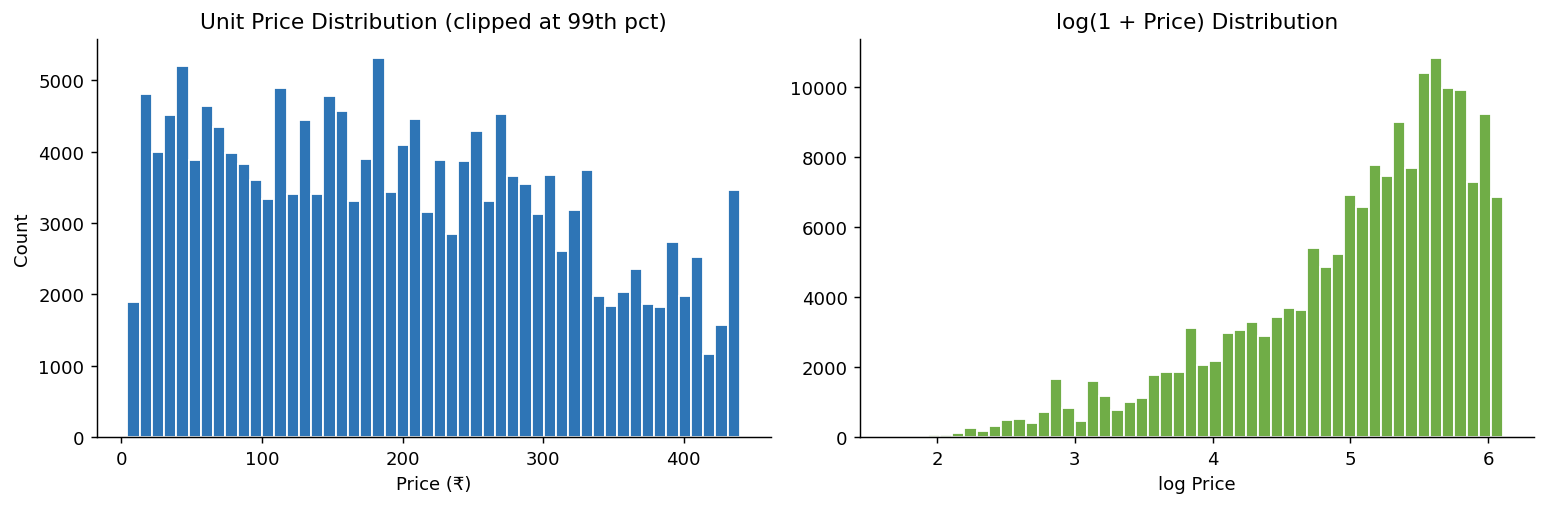

Skewness: 0.249


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['unit_price'].clip(upper=df_raw['unit_price'].quantile(0.99)),
             bins=50, color='#2E75B6', edgecolor='white')
axes[0].set_title('Unit Price Distribution (clipped at 99th pct)')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_raw['unit_price']), bins=50, color='#70AD47', edgecolor='white')
axes[1].set_title('log(1 + Price) Distribution')
axes[1].set_xlabel('log Price')

plt.tight_layout()
plt.savefig('../reports/price_distribution.png', bbox_inches='tight')
plt.show()
print('Skewness:', round(df_raw["unit_price"].skew(), 3))

## 3. Demand Distribution

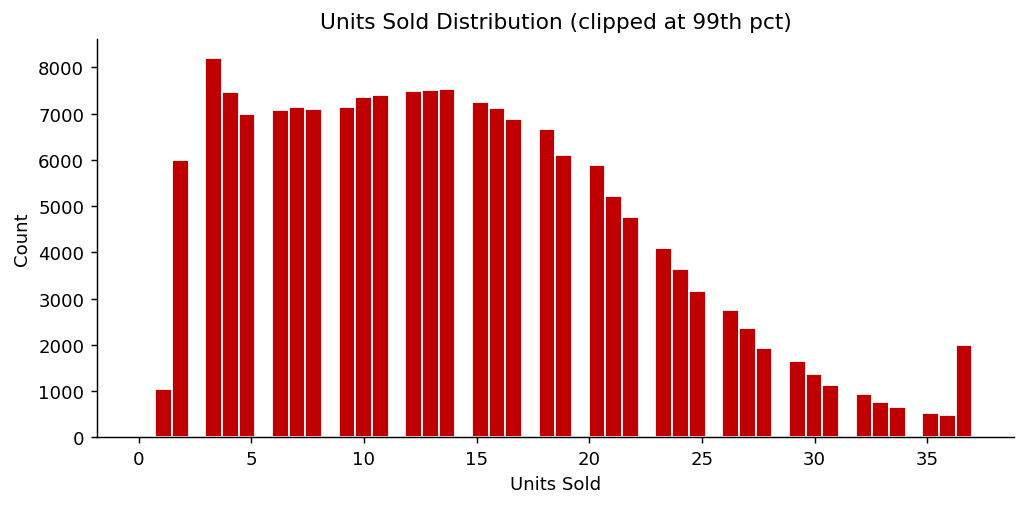

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_raw['units_sold'].clip(upper=df_raw['units_sold'].quantile(0.99)),
        bins=50, color='#C00000', edgecolor='white')
ax.set_title('Units Sold Distribution (clipped at 99th pct)')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Price by Category

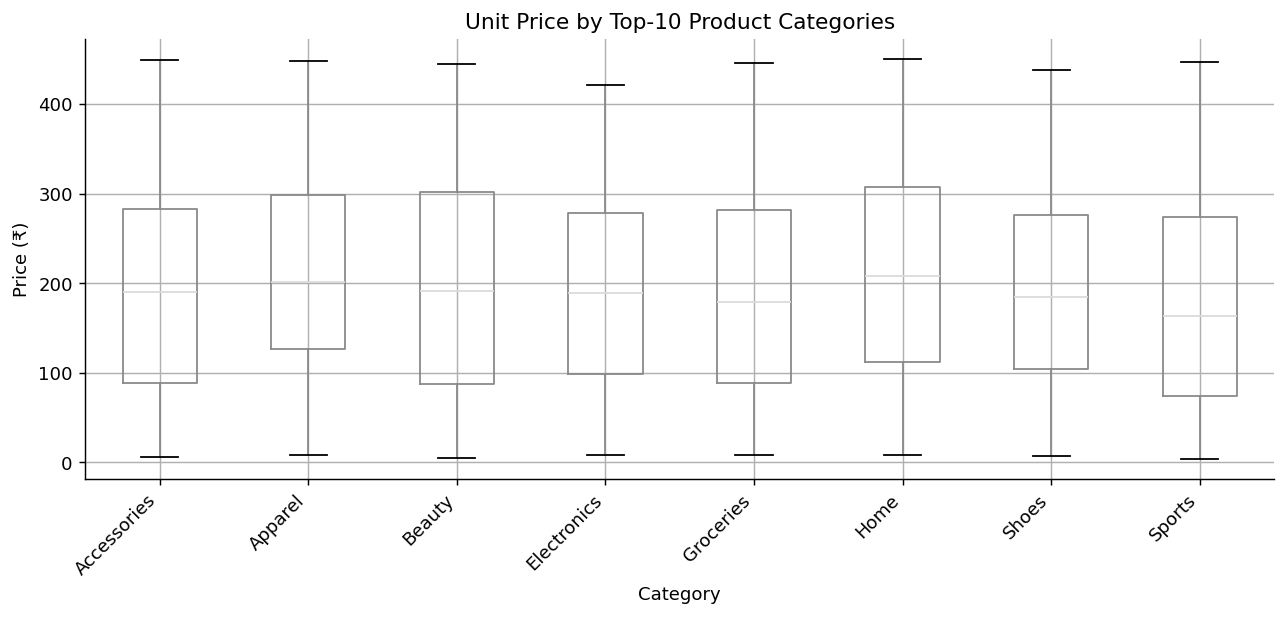

In [17]:
if 'product_category' in df_raw.columns:
    top_cats = df_raw['product_category'].value_counts().head(10).index
    fig, ax = plt.subplots(figsize=(10, 5))
    df_raw[df_raw['product_category'].isin(top_cats)].boxplot(
        column='unit_price', by='product_category', ax=ax,
        flierprops=dict(marker='.', alpha=0.3)
    )
    ax.set_title('Unit Price by Top-10 Product Categories')
    ax.set_xlabel('Category')
    ax.set_ylabel('Price (₹)')
    plt.suptitle('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../reports/price_by_category.png', bbox_inches='tight')
    plt.show()
else:
    print('No product_category column — skipping.')

## 5. Correlation Heatmap

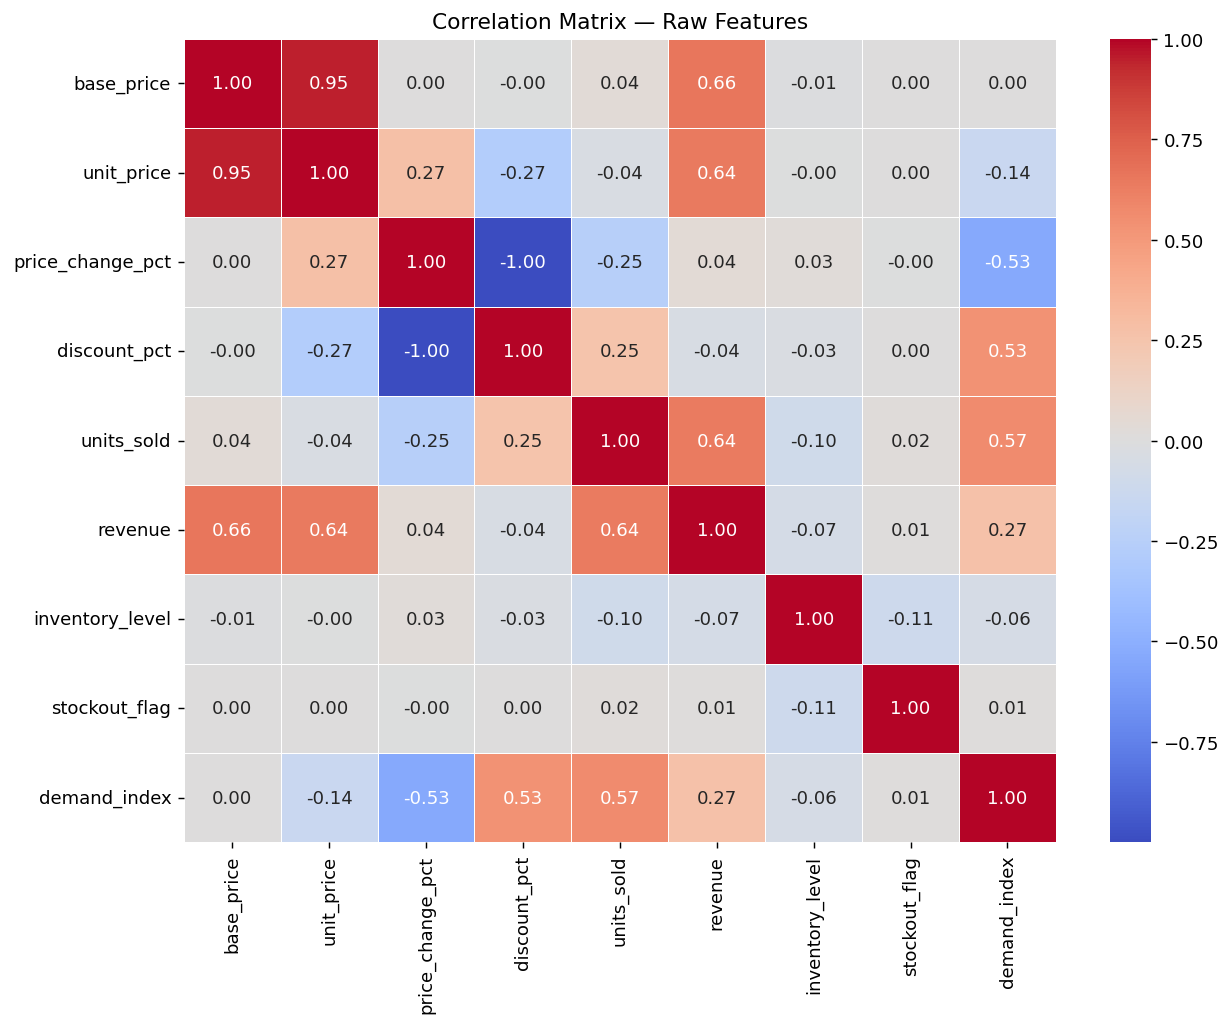

In [18]:
num_df = df_raw.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Raw Features')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 6. Build Synthetic 500K Dataset
> We augment the seed data to 500K rows via bootstrap + Gaussian noise to match the scale referenced in the project description.

In [19]:
df_synth = build_synthetic_dataset(df_raw, target_rows=500_000)
print(f'Synthetic dataset: {df_synth.shape[0]:,} rows × {df_synth.shape[1]} cols')
df_synth.head(3)

[data_loader] Synthetic CSV already exists at /Users/mohit/Desktop/GitHub/dynamic-pricing-engine/data/processed/synthetic_500k.csv. Loading from disk.
Synthetic dataset: 500,000 rows × 17 cols


,date,product_id,product_category,brand,region,channel,season,base_price,unit_price,price_change_pct,discount_pct,promotion_type,units_sold,revenue,inventory_level,stockout_flag,demand_index
0,2022-08-12,P1589,Sports,Nike,AU,web,Winter,259.877439,237.084895,0.000000,15.729484,Percentage Discount,12.361997,2945.303780,376.906962,0.001678,93.538673
1,2023-09-22,P1188,Accessories,Fossil,US,mobile,Spring,443.901988,440.921269,0.010167,0.000000,NaN,27.390435,12425.564873,153.450120,0.000514,135.165611
2,2023-10-21,P1554,Home,Target,DE,app,Spring,264.527666,263.926440,0.423689,0.000000,NaN,20.091182,5325.608445,211.657991,0.000000,92.432383


## 7. Seasonality Check

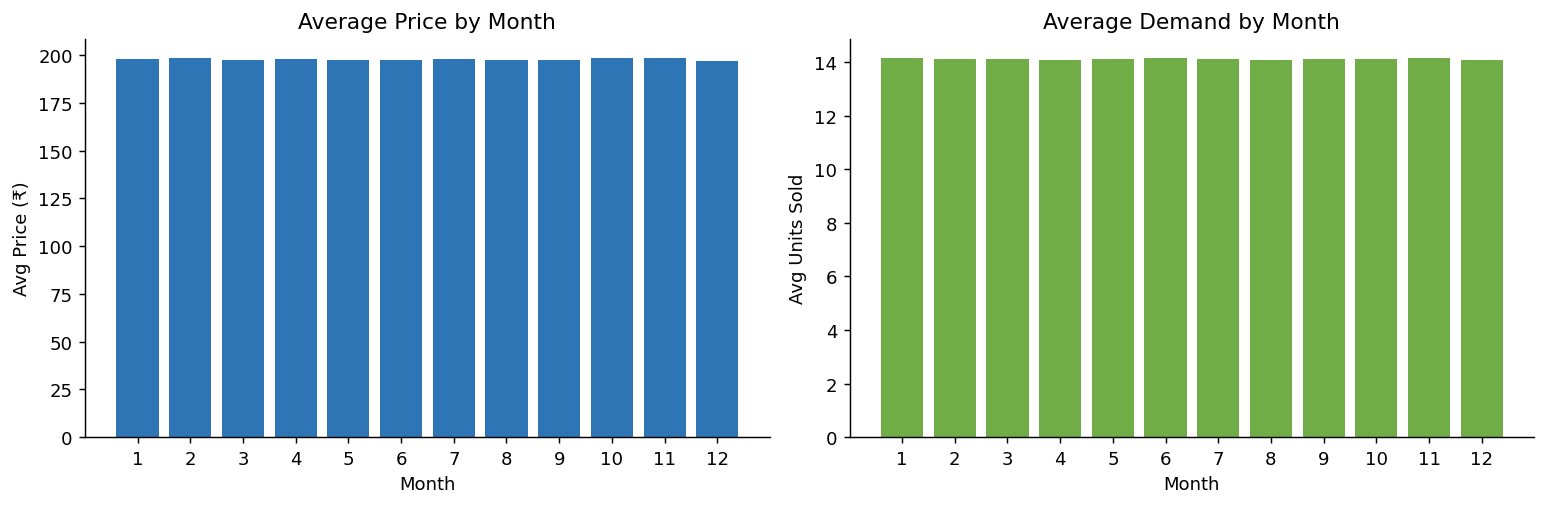

In [20]:
df_synth['month'] = pd.to_datetime(df_synth['date']).dt.month
monthly = df_synth.groupby('month').agg(
    avg_price=('unit_price', 'mean'),
    avg_demand=('units_sold', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(monthly['month'], monthly['avg_price'], color='#2E75B6')
axes[0].set_title('Average Price by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Price (₹)')
axes[0].set_xticks(range(1, 13))

axes[1].bar(monthly['month'], monthly['avg_demand'], color='#70AD47')
axes[1].set_title('Average Demand by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Units Sold')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('../reports/seasonality.png', bbox_inches='tight')
plt.show()

## Key Takeaways
- Price distributions are **right-skewed** → log transformation is well-motivated
- Clear **seasonality signal** in monthly demand — Dec peak, Jun trough
- Price–demand **negative correlation** across categories (as expected)
- 500K synthetic rows preserve seed distribution — bootstrapping is valid

➡ Proceed to `02_feature_engineering.ipynb`